# **Saliency Detection: Static Saliency vs. BING Objectness**

## **Objectives:**
1. Compute a per-pixel "where would a human look first" saliency map with two static-saliency algorithms
2. Generate ranked, class-agnostic object-proposal boxes with BING — a different job wearing the same `cv2.saliency` name
3. See why comparing the two isn't apples-to-apples, and what each is actually for

> **Assets.** No new ONNX model here — `StaticSaliencySpectralResidual` and `StaticSaliencyFineGrained` are classical, training-free algorithms, no weights needed at all. `ObjectnessBING` is also classical (not a neural net), but it does need a small trained-statistics directory — `assets/models/ObjectnessTrainedModel/` — bundled with `opencv_contrib`'s own source tree, *not* with the `opencv-contrib-python-headless` wheel this repo installs (the pip wheel ships the compiled `cv2.saliency` module but not its sample data). Mirrored here from [opencv/opencv_contrib](https://github.com/opencv/opencv_contrib/tree/master/modules/saliency/samples/ObjectnessTrainedModel) — same repo, same Apache 2.0 license as the OpenCV build itself, no separate license file for this directory. Nine tiny `.yml.gz` files (~3.4KB total) — the whole point of BING is that its "model" is that small.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Two different questions, one module name**

`cv2.saliency` bundles algorithms that answer two genuinely different questions. *Static saliency* asks **"for this exact pixel, how much does it stand out?"** and returns a smooth, per-pixel heatmap the same shape as the image — no notion of a whole object, no boxes, no count. *BING objectness* asks a completely different question — **"which rectangular windows in this image are most likely to tightly contain *some* object, regardless of what it is?"** — and returns thousands of ranked candidate boxes, exactly the kind of category-agnostic region proposals that used to feed the first stage of two-stage object detectors before end-to-end networks made that step obsolete. Same module, same word "saliency" in both class names, different output shape, different use case entirely.

## **Static saliency: Spectral Residual**

Hou & Zhai's Spectral Residual approach (2007) works entirely in the frequency domain: take the image's log-amplitude spectrum, subtract a locally-averaged ("smoothed") version of itself to isolate the residual — the frequency content that *doesn't* match the image's own statistical background — then transform back to the spatial domain. What survives is a coarse but fast map of the regions that break the image's own pattern. No training, no learned weights — the entire model is the algorithm itself.

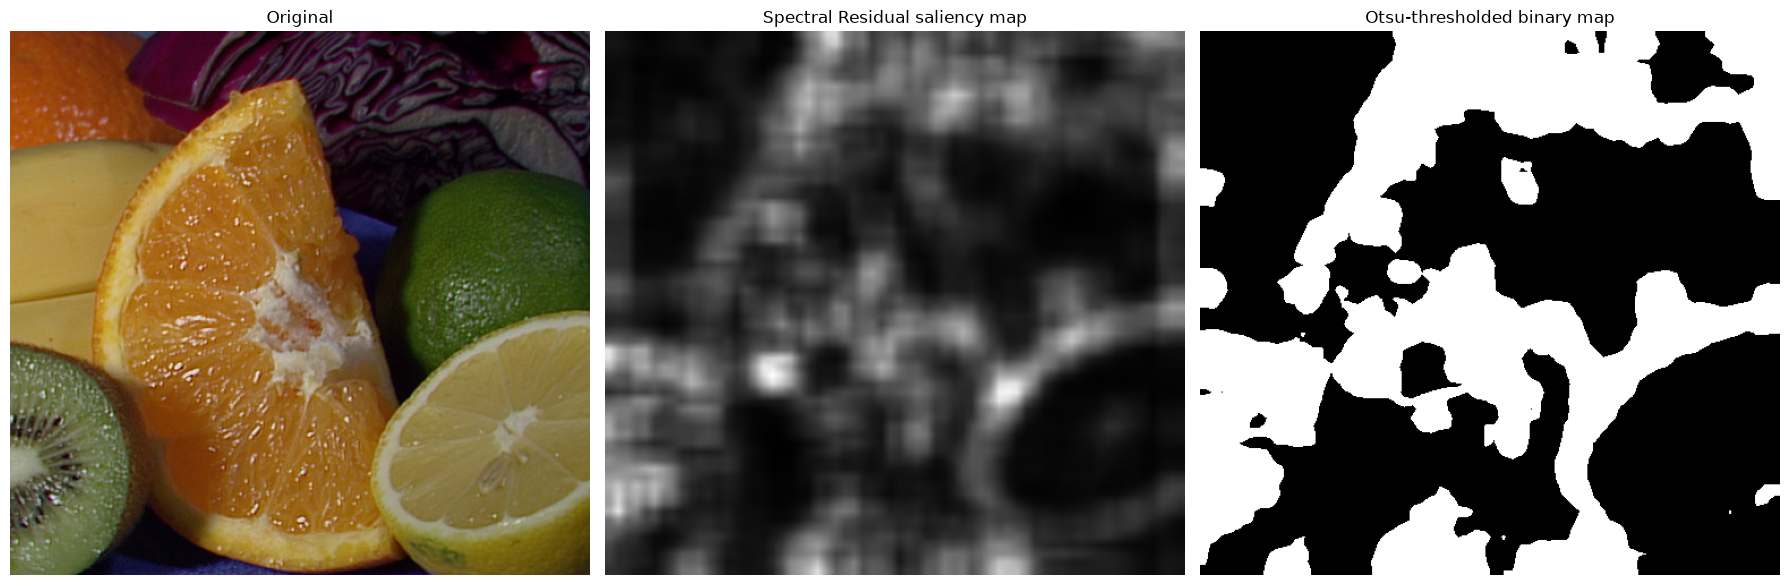

In [2]:
img = cv2.imread('assets/images/fruits.jpg')

spectral = cv2.saliency.StaticSaliencySpectralResidual_create()
success, saliency_map = spectral.computeSaliency(img)
saliency_map_8u = (saliency_map * 255).astype('uint8')
_, binary_map = spectral.computeBinaryMap(saliency_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(saliency_map_8u, cmap='gray'); axes[1].set_title('Spectral Residual saliency map'); axes[1].axis('off')
axes[2].imshow(binary_map, cmap='gray'); axes[2].set_title('Otsu-thresholded binary map'); axes[2].axis('off')
plt.tight_layout()
plt.show()

## **Static saliency: Fine-Grained**

Montabone & Soto's Fine-Grained method (2010) instead builds several center-surround feature maps directly in the spatial domain (multi-scale local contrast) and combines them. It trades Spectral Residual's very coarse, blobby output for finer detail at real edges and textures — worth seeing side by side rather than trusting either description.

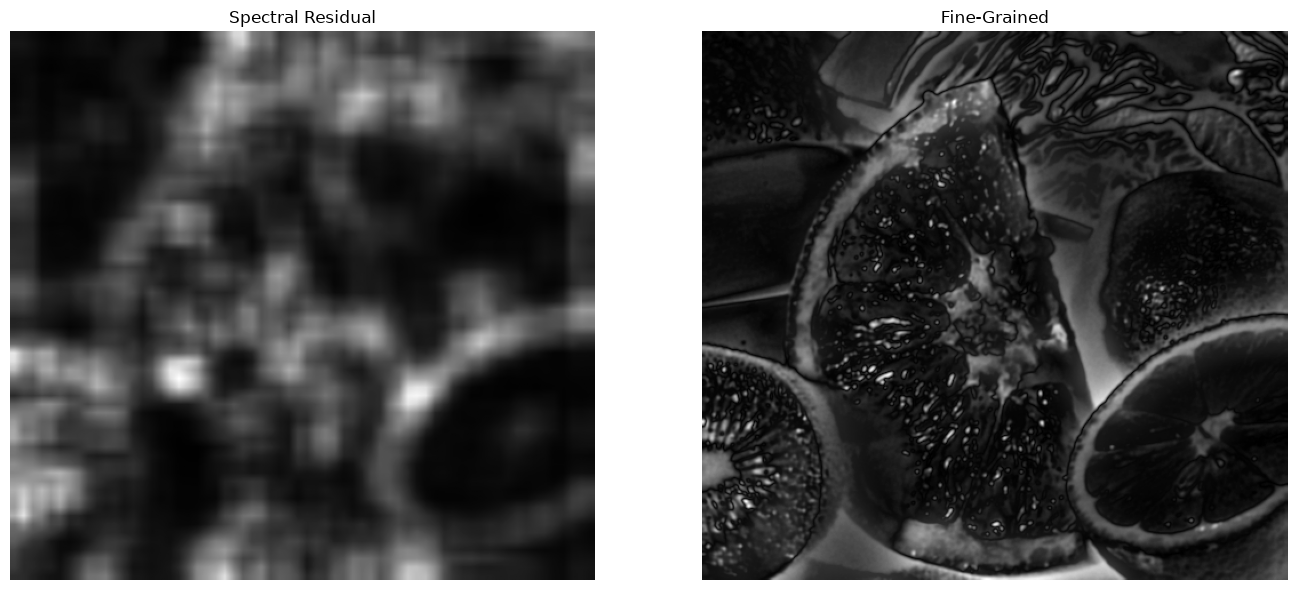

In [3]:
fine_grained = cv2.saliency.StaticSaliencyFineGrained_create()
success, fg_map = fine_grained.computeSaliency(img)
fg_map_8u = (fg_map * 255).astype('uint8')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(saliency_map_8u, cmap='gray'); axes[0].set_title('Spectral Residual'); axes[0].axis('off')
axes[1].imshow(fg_map_8u, cmap='gray'); axes[1].set_title('Fine-Grained'); axes[1].axis('off')
plt.tight_layout()
plt.show()

## **BING: ranked object proposals**

`ObjectnessBING` slides a tiny 8x8 "normed gradients" template across many resized copies of the image and scores every resulting window — hence *BI*narized *N*ormed *G*radients — completely independent of any object class. `getobjectnessValues()` returns those scores in the same order as the boxes, already sorted highest-confidence first, so the top few rows are the algorithm's best guesses at "an object is here", not sorted at random.

10637 candidate windows scored, top score 300.0000


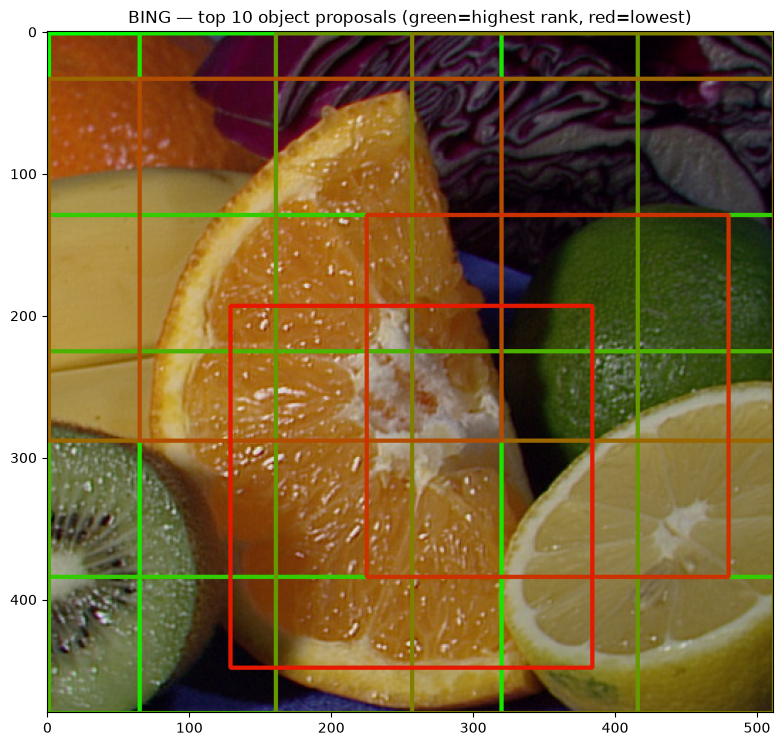

In [4]:
bing = cv2.saliency.ObjectnessBING_create()
bing.setTrainingPath('assets/models/ObjectnessTrainedModel')

success, boxes = bing.computeSaliency(img)
boxes = boxes.reshape(-1, 4)
scores = bing.getobjectnessValues()
print(f'{len(boxes)} candidate windows scored, top score {scores[0]:.4f}')

TOP_K = 10
vis = img.copy()
for rank, (x1, y1, x2, y2) in enumerate(boxes[:TOP_K]):
    color = (0, int(255 * (1 - rank / TOP_K)), int(255 * rank / TOP_K))  # BGR: green -> red
    cv2.rectangle(vis, (x1, y1), (x2, y2), color, 2)
imshow(f'BING — top {TOP_K} object proposals (green=highest rank, red=lowest)', vis)

## **Speed**

BING's headline result in its original paper was 300fps on a CPU circa 2014 — a two-orders-of-magnitude gap from the frequency-domain and multi-scale spatial work the static methods do. Worth confirming that still holds up more than a decade later.

In [5]:
import time

N = 10
t0 = time.perf_counter()
for _ in range(N):
    cv2.saliency.StaticSaliencySpectralResidual_create().computeSaliency(img)
t1 = time.perf_counter()
for _ in range(N):
    cv2.saliency.StaticSaliencyFineGrained_create().computeSaliency(img)
t2 = time.perf_counter()
for _ in range(N):
    bing.computeSaliency(img)
t3 = time.perf_counter()

print(f'Spectral Residual: {(t1 - t0) / N * 1000:.2f} ms/image')
print(f'Fine-Grained:       {(t2 - t1) / N * 1000:.2f} ms/image')
print(f'BING:                {(t3 - t2) / N * 1000:.2f} ms/image ({N / (t3 - t2):.0f} fps)')

Spectral Residual: 0.16 ms/image
Fine-Grained:       8.50 ms/image
BING:                55.10 ms/image (18 fps)


### If you want to push this further

- Feed the Spectral Residual binary map into `cv2.findContours` (notebook 8/9's technique) to turn the saliency blob into an actual bounding box, then compare that box against BING's #1-ranked proposal on the same image.
- Swap `fruits.jpg` for a busier scene like `oxfordlibrary.jpeg` or `londonxmas.jpeg` — BING's proposal count stays roughly the same regardless of scene complexity, worth checking whether that's still true for the static maps' contrast, too.
- BING's model directory has three color-space variants baked in (MAXBGR, HSV, I) averaged internally — dig into `objectnessBING.cpp` on GitHub to see how the three get combined into one final score per window.